# 02 - Trực quan dữ liệu sau khi làm sạch

Notebook này tập trung vào clean train split và chỉ sử dụng dữ liệu đã làm sạch theo contract hiện tại.

Phạm vi dữ liệu:
- `review_id`
- `content`
- các cột nhãn multi-task
- các feature EDA được trích xuất từ clean split

Các biểu đồ gồm:
- bảng thống kê mô tả nhanh
- số khía cạnh được nhắc đến theo sentiment
- biểu đồ tròn sentiment
- histogram số từ
- histogram số ký tự theo sentiment
- boxplot độ dài review theo sentiment
- phân phối bucket độ dài review
- độ phủ khía cạnh và cấu trúc sentiment
- bảng xem trước dữ liệu
- dashboard n-gram
- word cloud
- chiếu 3D TF-IDF + t-SNE


## Ảnh xem trước trên GitHub

![Dataset snapshot](assets/eda_snapshot.png)

Ảnh tĩnh này giúp notebook hiển thị tốt trên GitHub. Chạy notebook cục bộ để tạo lại các biểu đồ Matplotlib bên dưới.


In [56]:
from pathlib import Path
import json
import math
import statistics
import seaborn as sns
from IPython import get_ipython
import emoji
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.manifold import TSNE
from IPython.display import display
from wordcloud import WordCloud

ip = get_ipython()
if ip is not None:
    try:
        ip.run_line_magic("matplotlib", "inline")
    except Exception:
        plt.switch_backend("Agg")
else:
    plt.switch_backend("Agg")

sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "savefig.facecolor": "white",
        "axes.titlesize": 14,
        "axes.titleweight": "bold",
        "axes.labelsize": 11,
        "legend.frameon": False,
    }
)

pd.set_option("display.max_colwidth", 140)
pd.set_option("display.width", 180)


In [57]:
def avg_word_len(text: str) -> float:
    words = text.split()
    if not words:
        return 0.0
    return float(np.mean([len(word) for word in words]))


def count_emojis(text: str) -> int:
    try:
        return len(emoji.emoji_list(text))
    except Exception:
        return 0


def normalize_text_for_ngrams(text: str) -> str:
    text = text.lower()
    text = " ".join(text.split())
    return text


def sentiment_subset(frame: pd.DataFrame, label: str) -> pd.DataFrame:
    return frame.loc[frame["sentiment_name"] == label].copy()


def top_ngrams(texts, ngram_range=(2, 2), top_n=15):
    vectorizer = CountVectorizer(
        ngram_range=ngram_range,
        token_pattern=r"(?u)\b[\w_]+\b",
        min_df=2,
    )
    matrix = vectorizer.fit_transform(texts)
    if matrix.shape[1] == 0:
        return pd.DataFrame(columns=["ngram", "count"])
    counts = np.asarray(matrix.sum(axis=0)).ravel()
    items = pd.DataFrame(
        {
            "ngram": vectorizer.get_feature_names_out(),
            "count": counts,
        }
    )
    return items.sort_values("count", ascending=False).head(top_n)


def style_axes(ax, grid_axis="y"):
    sns.despine(ax=ax)
    ax.set_axisbelow(True)
    ax.grid(axis=grid_axis, color="#dfe3eb", linewidth=0.8, alpha=0.9)


def annotate_vertical_bars(ax, bars, values, fmt="{:,.0f}", offset_ratio=0.015, fontsize=10):
    values = list(values)
    peak = max(values) if values else 0
    offset = peak * offset_ratio if peak else 0.01
    for bar, value in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + offset,
            fmt.format(value),
            ha="center",
            va="bottom",
            fontsize=fontsize,
        )


def annotate_horizontal_bars(ax, bars, values, fmt="{:,.0f}", offset_ratio=0.01, fontsize=10):
    values = list(values)
    peak = max(values) if values else 0
    offset = peak * offset_ratio if peak else 0.01
    for bar, value in zip(bars, values):
        ax.text(
            bar.get_width() + offset,
            bar.get_y() + bar.get_height() / 2,
            fmt.format(value),
            ha="left",
            va="center",
            fontsize=fontsize,
        )


In [58]:
# 1. Cấu hình đường dẫn nhanh
def get_root():
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "data").exists():
            return p
    return Path.cwd()

ROOT = get_root()
DATA_PATH = ROOT / "data/processed/train_clean.json"
SCAN_PATH = ROOT / "experiments/reports/train_clean_scan.json"

# 2. Định nghĩa cấu hình hiển thị
SENTIMENT_COLORS = {"negative": "#d64b4b", "neutral": "#f0ad4e", "positive": "#2ca02c"}
SENTIMENT_DISPLAY = {"negative": "Tiêu cực", "neutral": "Trung lập", "positive": "Tích cực"}
SENTIMENT_ORDER = list(SENTIMENT_DISPLAY.keys())
SENTIMENT_MAP = {0: "negative", 1: "neutral", 2: "positive"}


def display_sentiment(label: str) -> str:
    return SENTIMENT_DISPLAY.get(label, str(label))


def display_aspect(aspect: str) -> str:
    return ASPECT_DISPLAY.get(aspect, aspect.replace("as_", "").capitalize())


ASPECT_DISPLAY = {
    "as_content": "Nội dung",
    "as_physical": "Chất lượng",
    "as_price": "Giá",
    "as_packaging": "Đóng gói",
    "as_delivery": "Giao hàng",
    "as_service": "Dịch vụ",
}
ASPECT_COLS = list(ASPECT_DISPLAY.keys())

df = pd.read_json(DATA_PATH)
ID_COL = "review_id"
df["content"] = df["content"].fillna("").astype(str)

with open(SCAN_PATH, encoding="utf-8") as f:
    report = json.load(f)


def show_summary(report):
    c = report["checks"]
    metrics = {
        "Số dòng": len(df),
        "Thiếu content": c["missing_values"]["per_column"]["content"]["missing_count"],
        "Dòng lỗi mã hóa": c["encoding"]["rows_with_any_issue"],
        "Dòng nhiễu": c["noise_patterns"]["rows_with_any_noise"],
        "Dòng có emoji": c["emoji"]["rows_with_emoji"],
        "Bản sao trùng": c["duplicates"]["normalized_duplicate_texts"],
    }
    display(pd.DataFrame([metrics], index=["Sau làm sạch"]).T)

print(f"Đã load {len(df):,} dòng dữ liệu sạch từ: {DATA_PATH.name}")
show_summary(report)


Đã load 9,362 dòng dữ liệu sạch từ: train_clean.json


,Sau làm sạch
Số dòng,9362
Thiếu content,0
Dòng lỗi mã hóa,23
Dòng nhiễu,593
Dòng có emoji,0
Bản sao trùng,2


In [59]:
df["sentiment_name"] = df["sentiment_llm"].map(SENTIMENT_MAP).fillna("unknown")
df["word_count"] = df["content"].apply(lambda x: len(x.split()))
df["char_count"] = df["content"].str.len()
df["avg_word_len"] = df["content"].apply(avg_word_len)
df["lexical_diversity"] = df["content"].apply(lambda x: len(set(x.split())) / (len(x.split()) + 1))
df["caps_ratio"] = df["content"].apply(lambda x: sum(1 for c in x if c.isupper()) / (len(x) + 1))
df["aspect_mentioned_count"] = df[ASPECT_COLS].notna().sum(axis=1)
df["review_length_bucket"] = pd.cut(
    df["char_count"],
    bins=[0, 10, 20, 50, 100, 200, 500, 10_000],
    right=False,
)

display(
    df[
        [
            ID_COL,
            "sentiment_name",
            "content",
            "word_count",
            "char_count",
            "avg_word_len",
            "lexical_diversity",
            "caps_ratio",
            "aspect_mentioned_count",
        ]
    ].head(5)
)


,review_id,sentiment_name,content,word_count,char_count,avg_word_len,lexical_diversity,caps_ratio,aspect_mentioned_count
0,20146420,positive,"Sách về tay đẹp, không tì vết.",7,30,3.428571,0.875000,0.032258,1
1,18374869,positive,Cực kì hài lòng,4,15,3.000000,0.800000,0.062500,0
2,19483431,positive,In ấn đảm bảo. May mắn không tốn phí giao_hàng.,10,47,3.800000,0.909091,0.041667,2
3,20203740,positive,"Giao hàng rất nhanh, cuốn sách rất hay và đẹp ạ.",11,48,3.454545,0.833333,0.020408,3
4,12927963,negative,Đọc không hiểu,3,14,4.000000,0.750000,0.066667,0


## Bảng thống kê mô tả nhanh


In [60]:
summary_cols = [
    "word_count",
    "char_count",
    "avg_word_len",
    "lexical_diversity",
    "aspect_mentioned_count",
]

summary_table = (
    df[summary_cols]
    .agg(["mean", "median", "std", "min", "max"])
    .T
    .round(2)
    .rename(
        columns={
            "mean": "Trung bình",
            "median": "Trung vị",
            "std": "Độ lệch chuẩn",
            "min": "Nhỏ nhất",
            "max": "Lớn nhất",
        }
    )
)
summary_table.index = [
    "Số từ",
    "Số ký tự",
    "Độ dài từ trung bình",
    "Độ đa dạng từ vựng",
    "Số khía cạnh được nhắc đến",
]
display(summary_table)

length_by_sentiment = (
    df.groupby("sentiment_name")[["word_count", "char_count", "aspect_mentioned_count"]]
    .agg(["mean", "median"])
    .round(2)
)
length_by_sentiment.index = [display_sentiment(label) for label in length_by_sentiment.index]
length_by_sentiment.columns = [
    (
        "Số từ" if col == "word_count" else "Số ký tự" if col == "char_count" else "Số khía cạnh",
        "Trung bình" if stat == "mean" else "Trung vị",
    )
    for col, stat in length_by_sentiment.columns
]
display(length_by_sentiment)


,Trung bình,Trung vị,Độ lệch chuẩn,Nhỏ nhất,Lớn nhất
Số từ,27.40,17.00,33.37,1.00,526.00
Số ký tự,124.98,76.00,159.05,10.00,3042.00
Độ dài từ trung bình,3.67,3.51,2.46,2.00,192.33
Độ đa dạng từ vựng,0.87,0.89,0.07,0.03,0.98
Số khía cạnh được nhắc đến,1.25,1.00,0.98,0.00,6.00


,"(Số từ, Trung bình)","(Số từ, Trung vị)","(Số ký tự, Trung bình)","(Số ký tự, Trung vị)","(Số khía cạnh, Trung bình)","(Số khía cạnh, Trung vị)"
Tiêu cực,30.28,20.0,136.90,90.0,1.14,1.0
Trung lập,25.54,16.0,117.87,74.0,1.14,1.0
Tích cực,23.53,13.0,108.68,60.0,1.49,1.0


## Phân phối độ dài review


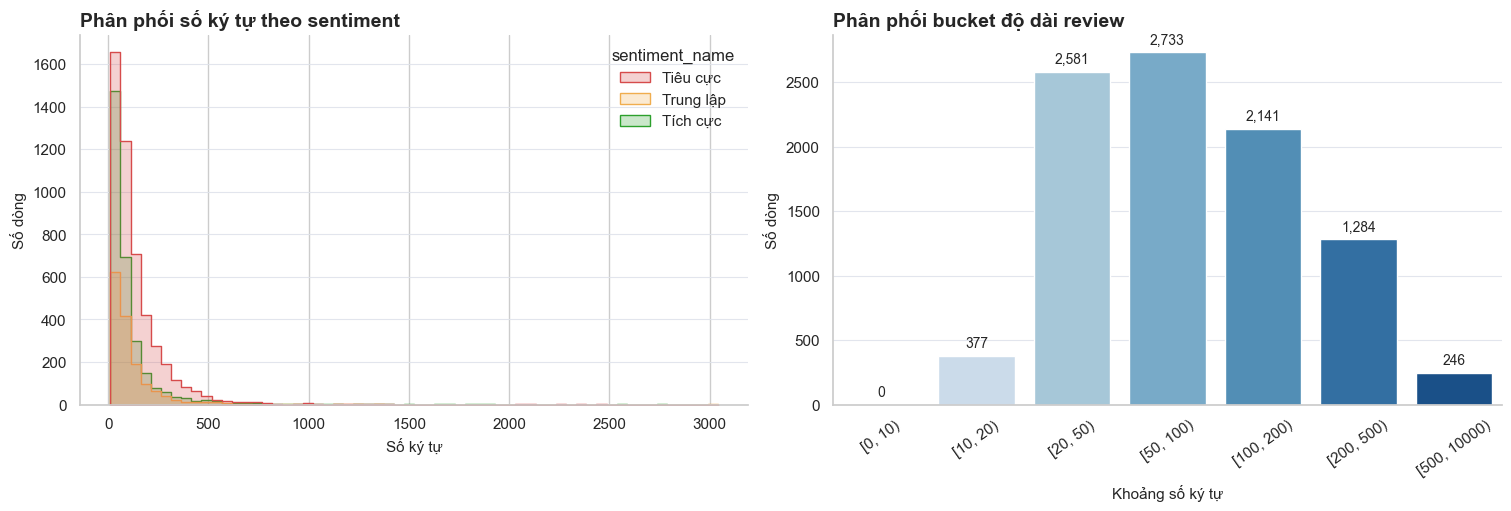

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)

sns.histplot(
    data=df,
    x="char_count",
    hue="sentiment_name",
    hue_order=SENTIMENT_ORDER,
    palette=SENTIMENT_COLORS,
    bins=60,
    element="step",
    stat="count",
    common_norm=False,
    ax=axes[0],
)
axes[0].set_title("Phân phối số ký tự theo sentiment", loc="left", fontweight="bold")
axes[0].set_xlabel("Số ký tự")
axes[0].set_ylabel("Số dòng")
style_axes(axes[0])
legend = axes[0].get_legend()
if legend:
    for text, label in zip(legend.texts, SENTIMENT_ORDER):
        text.set_text(display_sentiment(label))

bucket_counts = (
    df["review_length_bucket"]
    .value_counts(sort=False)
    .rename_axis("bucket")
    .reset_index(name="count")
)
bucket_counts["bucket_label"] = bucket_counts["bucket"].astype(str)
sns.barplot(
    data=bucket_counts,
    x="bucket_label",
    y="count",
    hue="bucket_label",
    dodge=False,
    palette="Blues",
    legend=False,
    ax=axes[1],
)
annotate_vertical_bars(axes[1], axes[1].patches, bucket_counts["count"])
axes[1].set_title("Phân phối bucket độ dài review", loc="left", fontweight="bold")
axes[1].set_xlabel("Khoảng số ký tự")
axes[1].set_ylabel("Số dòng")
axes[1].tick_params(axis="x", rotation=35)
style_axes(axes[1])

plt.show()


## Boxplot độ dài theo sentiment


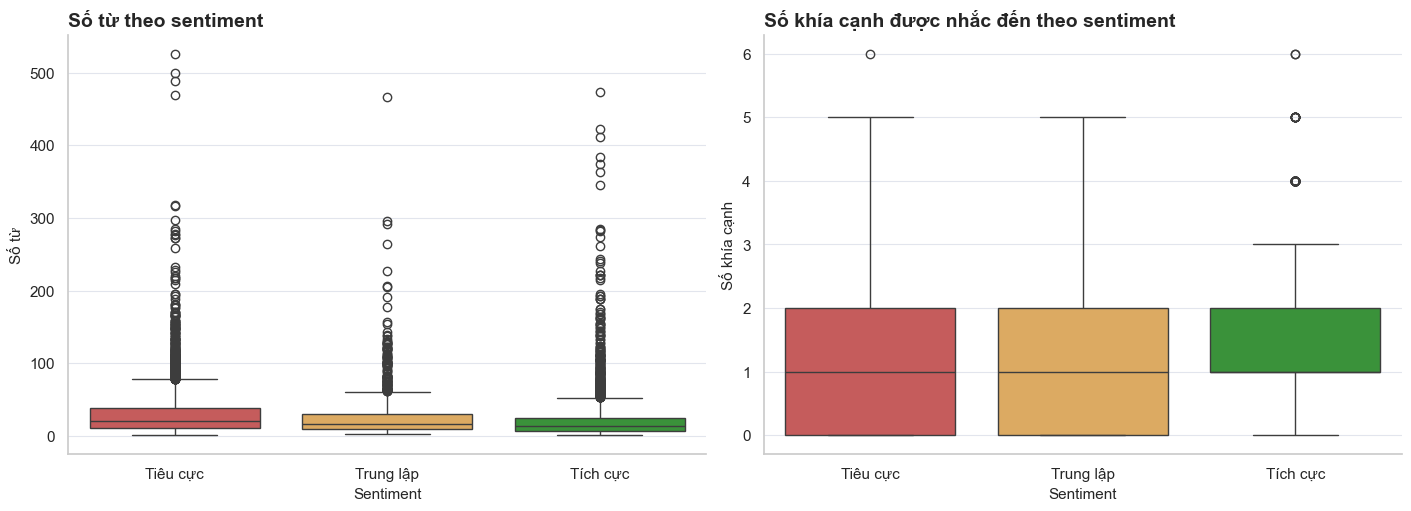

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

sns.boxplot(
    data=df,
    x="sentiment_name",
    y="word_count",
    hue="sentiment_name",
    order=SENTIMENT_ORDER,
    hue_order=SENTIMENT_ORDER,
    palette=SENTIMENT_COLORS,
    dodge=False,
    legend=False,
    ax=axes[0],
)
axes[0].set_title("Số từ theo sentiment", loc="left", fontweight="bold")
axes[0].set_xlabel("Sentiment")
axes[0].set_ylabel("Số từ")
axes[0].set_xticks(range(len(SENTIMENT_ORDER)))
axes[0].set_xticklabels([display_sentiment(label) for label in SENTIMENT_ORDER])
style_axes(axes[0])

sns.boxplot(
    data=df,
    x="sentiment_name",
    y="aspect_mentioned_count",
    hue="sentiment_name",
    order=SENTIMENT_ORDER,
    hue_order=SENTIMENT_ORDER,
    palette=SENTIMENT_COLORS,
    dodge=False,
    legend=False,
    ax=axes[1],
)
axes[1].set_title("Số khía cạnh được nhắc đến theo sentiment", loc="left", fontweight="bold")
axes[1].set_xlabel("Sentiment")
axes[1].set_ylabel("Số khía cạnh")
axes[1].set_xticks(range(len(SENTIMENT_ORDER)))
axes[1].set_xticklabels([display_sentiment(label) for label in SENTIMENT_ORDER])
style_axes(axes[1])

plt.show()


## Khám phá review ngẫu nhiên


--- THONG TIN REVIEW [Index: 8443] ---
Review ID: 4505693
Cam xuc: Tiêu cực

NOI DUNG DA LAM SACH:
quyển này ghi là có Audio cd mà chỉ có sách, không có thêm đĩa nghe


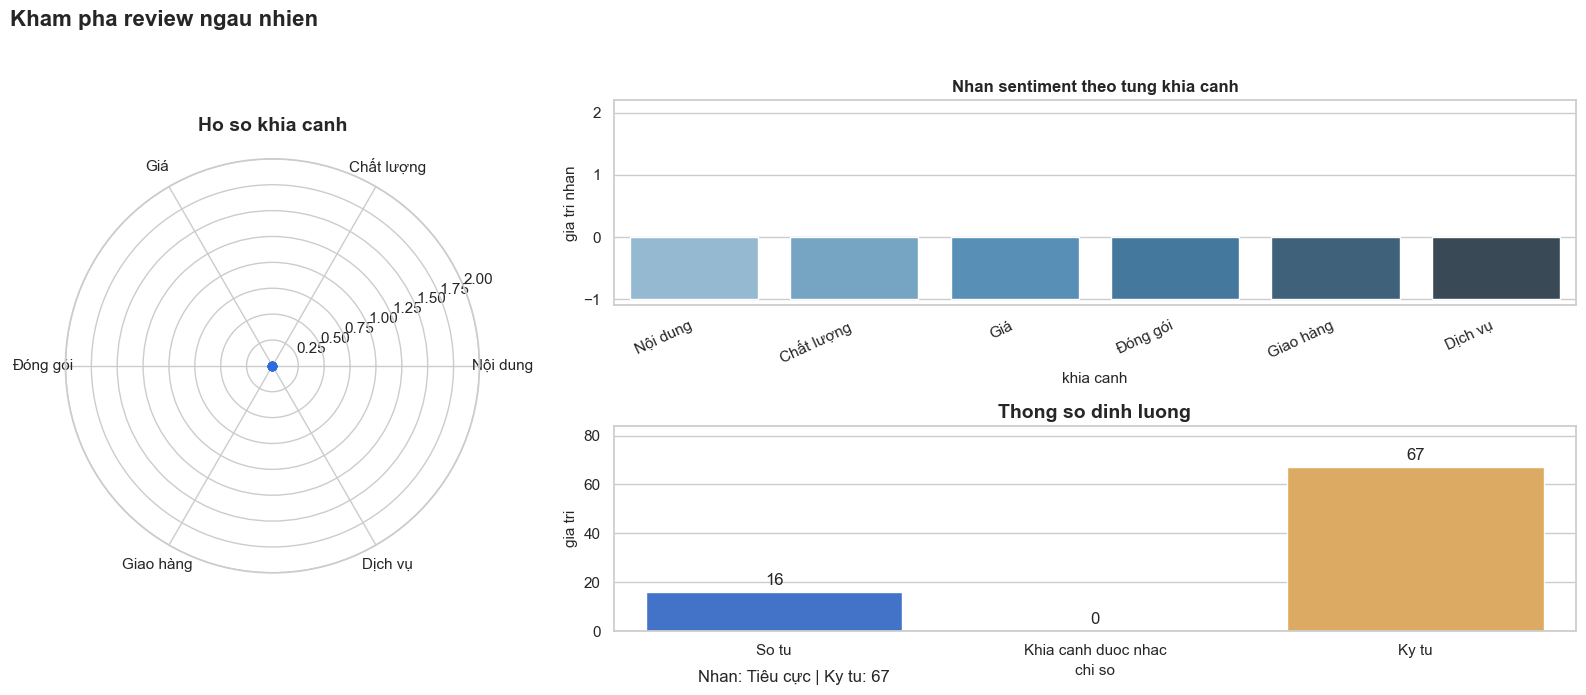

,Loai,Noi dung
0,NOI DUNG DA LAM SACH,"quyển này ghi là có Audio cd mà chỉ có sách, không có thêm đĩa nghe"


In [63]:
def inspect_review(df, idx=None):
    if idx is None:
        idx = np.random.choice(df.index)

    sample = df.loc[idx]

    print(f"--- THONG TIN REVIEW [Index: {idx}] ---")
    print(f"Review ID: {sample['review_id']}")
    print(f"Cam xuc: {display_sentiment(sample['sentiment_name'])}")
    print("\nNOI DUNG DA LAM SACH:")
    print(sample['content'])

    fig = plt.figure(figsize=(16, 7))
    grid = fig.add_gridspec(2, 3)

    ax_radar = fig.add_subplot(grid[:, 0], projection="polar")
    aspect_vals = sample[ASPECT_COLS].fillna(0).values
    angles = np.linspace(0, 2 * np.pi, len(ASPECT_COLS), endpoint=False).tolist()
    vals = np.concatenate((aspect_vals, [aspect_vals[0]]))
    angs = np.concatenate((angles, [angles[0]]))

    ax_radar.plot(angs, vals, 'o-', linewidth=2, color='#2d6cdf')
    ax_radar.fill(angs, vals, alpha=0.25, color='#2d6cdf')
    ax_radar.set_thetagrids(np.degrees(angles), [display_aspect(a) for a in ASPECT_COLS])
    ax_radar.set_ylim(0, 2)
    ax_radar.set_title("Ho so khia canh", pad=20, fontweight='bold')

    ax_sent = fig.add_subplot(grid[0, 1:])
    aspect_summary = pd.DataFrame({
        'aspect': [display_aspect(col) for col in ASPECT_COLS],
        'value': sample[ASPECT_COLS].fillna(-1).values,
    })
    sns.barplot(data=aspect_summary, x='aspect', y='value', hue='aspect', dodge=False, legend=False, ax=ax_sent, palette='Blues_d')
    ax_sent.set_title("Nhan sentiment theo tung khia canh", fontsize=12)
    ax_sent.set_xlabel("khia canh")
    ax_sent.set_ylabel("gia tri nhan")
    ax_sent.set_ylim(-1.1, 2.2)
    plt.setp(ax_sent.get_xticklabels(), rotation=25, ha='right')

    ax_stats = fig.add_subplot(grid[1, 1:])
    stats = {
        "So tu": sample['word_count'],
        "Khia canh duoc nhac": sample['aspect_mentioned_count'],
        "Ky tu": sample['char_count'],
    }
    stats_df = pd.DataFrame({"metric": list(stats.keys()), "value": list(stats.values())})
    sns.barplot(
        data=stats_df,
        x="metric",
        y="value",
        hue="metric",
        hue_order=stats_df["metric"].tolist(),
        ax=ax_stats,
        palette=sns.color_palette(["#2d6cdf", "#6c7a89", "#f0ad4e"]),
        errorbar=None,
        order=stats_df["metric"].tolist(),
        dodge=False,
        legend=False,
    )
    ax_stats.set_title("Thong so dinh luong")
    ax_stats.set_xlabel("chi so")
    ax_stats.set_ylabel("gia tri")
    ax_stats.set_ylim(0, max(stats_df["value"]) * 1.25 if not stats_df.empty else 1)
    for container in ax_stats.containers:
        ax_stats.bar_label(container, fmt="{:.0f}", padding=3)

    info_text = f"Nhan: {display_sentiment(sample['sentiment_name'])} | Ky tu: {sample['char_count']}"
    fig.text(0.5, 0.02, info_text, ha='center', bbox=dict(facecolor='white', alpha=0.5))
    fig.suptitle("Kham pha review ngau nhien", x=0.01, ha='left', fontsize=16, fontweight='bold')
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    text_info = pd.DataFrame({
        "Loai": ["NOI DUNG DA LAM SACH"],
        "Noi dung": [sample['content']],
    })
    from IPython.display import display
    display(text_info.style.set_properties(**{'text-align': 'left', 'white-space': 'pre-wrap'}))

# Chay thu
inspect_review(df)


## Biểu đồ cột: Số khía cạnh được nhắc đến trung bình theo sentiment


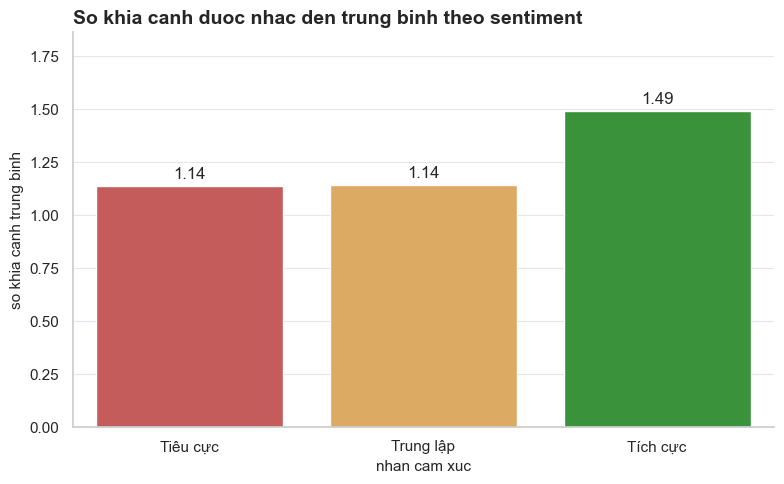

In [64]:
aspect_mentions_by_sentiment = (
    df.groupby("sentiment_name")["aspect_mentioned_count"]
    .mean()
    .reindex(SENTIMENT_ORDER)
    .fillna(0)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 5))
labels = aspect_mentions_by_sentiment["sentiment_name"].tolist()
display_labels = [display_sentiment(label) for label in labels]
values = aspect_mentions_by_sentiment["aspect_mentioned_count"].tolist()
plot_df = aspect_mentions_by_sentiment.assign(sentiment_display=display_labels)
sns.barplot(
    data=plot_df,
    x="sentiment_display",
    y="aspect_mentioned_count",
    hue="sentiment_display",
    hue_order=display_labels,
    ax=ax,
    palette=[SENTIMENT_COLORS[label] for label in labels],
    errorbar=None,
    order=display_labels,
    dodge=False,
    legend=False,
)
style_axes(ax)
ax.set_title("So khia canh duoc nhac den trung binh theo sentiment", loc="left")
ax.set_xlabel("nhan cam xuc")
ax.set_ylabel("so khia canh trung binh")
ax.set_ylim(0, max(values) * 1.25 if values else 1)
for container in ax.containers:
    ax.bar_label(container, fmt="{:.2f}", padding=3)
plt.tight_layout()
plt.show()


## Biểu đồ: Phân bố sentiment theo train/val/test


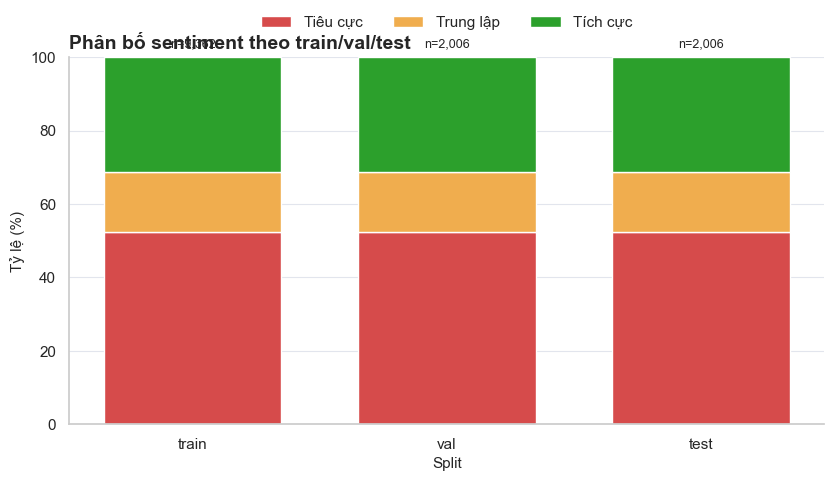

In [65]:
split_paths = {s: ROOT / f"data/processed/{s}_clean.json" for s in ("train", "val", "test")}
frames = {s: pd.read_json(p) for s, p in split_paths.items()}

def _sentiment_series(frame):
    if "sentiment_name" in frame.columns:
        return frame["sentiment_name"]
    return frame["sentiment_llm"].map(SENTIMENT_MAP).fillna("unknown")

counts = pd.DataFrame({
    split: _sentiment_series(frame).value_counts().reindex(SENTIMENT_ORDER).fillna(0).astype(int)
    for split, frame in frames.items()
}).T.reindex(columns=SENTIMENT_ORDER).fillna(0).astype(int)
pct = counts.div(counts.sum(axis=1), axis=0).mul(100)

fig, ax = plt.subplots(figsize=(8.5, 5))
bottom = np.zeros(len(counts))
for label in SENTIMENT_ORDER:
    vals = pct[label].to_numpy()
    ax.bar(counts.index, vals, bottom=bottom, width=0.7, color=SENTIMENT_COLORS[label], label=display_sentiment(label))
    bottom += vals

for x, split in enumerate(counts.index):
    ax.text(x, 102, f"n={counts.loc[split].sum():,}", ha="center", va="bottom", fontsize=9)

ax.set_ylim(0, 100)
ax.set_xlabel("Split")
ax.set_ylabel("Tỷ lệ (%)")
ax.set_title("Phân bố sentiment theo train/val/test", loc="left", fontweight="bold")
ax.legend(ncol=3, frameon=False, loc="upper center", bbox_to_anchor=(0.5, 1.15))
style_axes(ax)
plt.tight_layout()
plt.show()


Biểu đồ 100% stacked bar giúp so sánh nhanh tỷ lệ sentiment giữa train, val và test.

## Histogram: Phân bố số từ

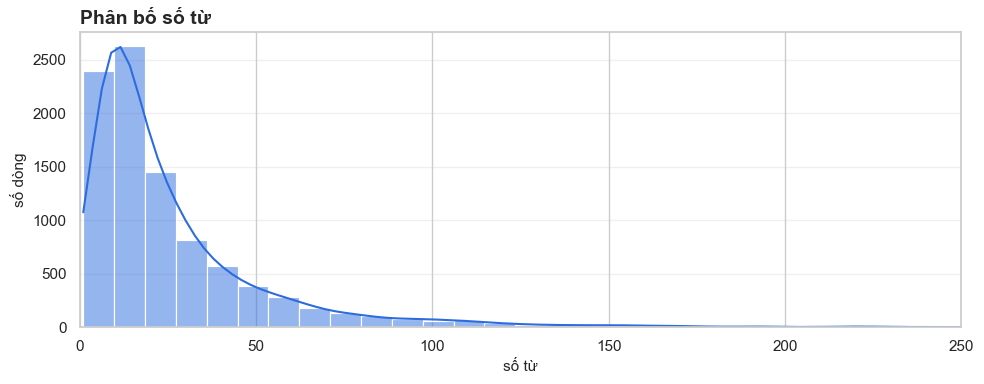

In [66]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(data=df, x="word_count", bins=60, color="#2d6cdf", kde=True, ax=ax, edgecolor="white")
ax.set_xlim(0, 250)
ax.set_title("Phân bố số từ ", loc="left", fontweight='bold')
ax.set_xlabel("số từ")
ax.set_ylabel("số dòng")
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [67]:
explore_df = df[
    [
        ID_COL,
        "content",
        "sentiment_name",
        "word_count",
        "char_count",
        "avg_word_len",
        "lexical_diversity",
        "caps_ratio",
        "aspect_mentioned_count",
    ]
].copy()

preview_df = explore_df.sample(min(len(explore_df), 5), random_state=42).sort_values([ID_COL])
display(preview_df)


,review_id,content,sentiment_name,word_count,char_count,avg_word_len,lexical_diversity,caps_ratio,aspect_mentioned_count
6196,6564990,"Sách viết không có những khái niệm cơ bản về Truyền thông nội bộ, chỉ đa phần là các cuộc phỏng vấn. Mà có lẽ người dịch cũng không thoá...",negative,40,180,3.525000,0.902439,0.016575,1
3884,13991514,"Ôi mặc dù chờ Dune đã lâu, cũng mong ngóng được đọc Xứ Cát rất nhiều nhưng em xin để lại 2 sao vì Tiki Trading đã khiến em đau khổ quá n...",negative,195,1042,4.348718,0.816327,0.014382,4
6237,16193173,sách không có đem lại kiến thức gì cho mình,negative,10,43,3.400000,0.909091,0.000000,1
8937,16632933,"Sách cũng khá hay đó ạ, giúp ta có những cái nhìn và hướng đi đúng đắn trong xã hội, cuộc sống. Màu giấy trắng ngà tránh mỏi mắt khi đọc.",positive,31,137,3.451613,0.968750,0.014493,1
1791,19412690,Tiki giao hàng nhanh. shipper dễ thương. Đóng gói kĩ và xịn xò ạ.,positive,14,65,3.714286,0.933333,0.030303,3


## Biểu đồ cột: Độ phủ của các khía cạnh


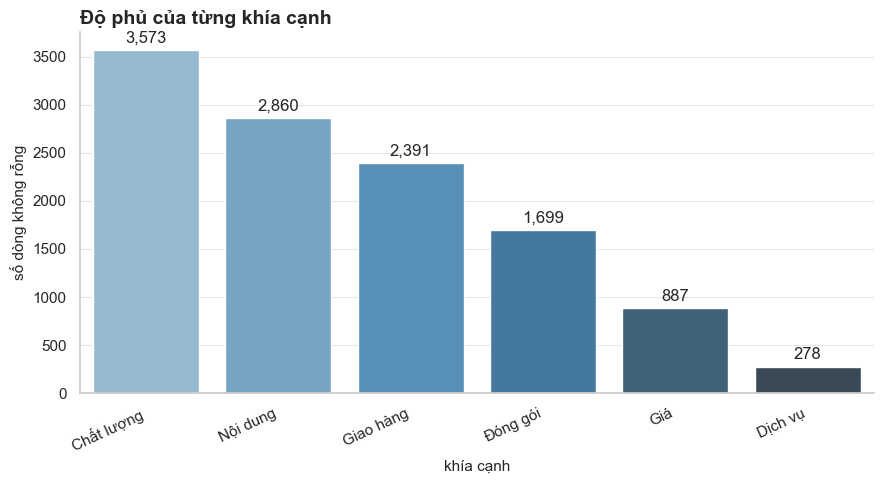

In [68]:
aspect_coverage = (
    df[ASPECT_COLS]
    .notna()
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
aspect_coverage.columns = ["aspect", "count"]
aspect_coverage["aspect_label"] = aspect_coverage["aspect"].map(display_aspect)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    data=aspect_coverage,
    x="aspect_label",
    y="count",
    hue="aspect_label",
    hue_order=aspect_coverage["aspect_label"].tolist(),
    ax=ax,
    palette=sns.color_palette("Blues_d", n_colors=len(aspect_coverage)),
    errorbar=None,
    order=aspect_coverage["aspect_label"].tolist(),
    dodge=False,
    legend=False,
)
plt.setp(ax.get_xticklabels(), rotation=25, ha="right")
style_axes(ax)
ax.set_title("Độ phủ của từng khía cạnh", loc="left")
ax.set_xlabel("khía cạnh")
ax.set_ylabel("số dòng không rỗng")
for container in ax.containers:
    ax.bar_label(container, fmt="{:,.0f}", padding=3)
plt.tight_layout()
plt.show()

## Biểu đồ cột chồng: Tỷ lệ sentiment trên 6 khía cạnh


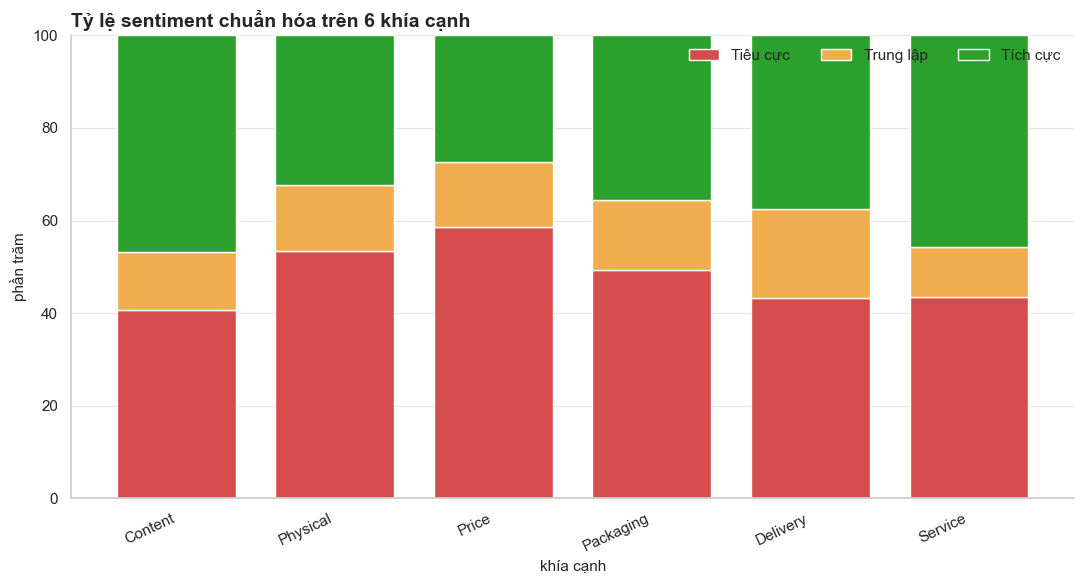

In [69]:
aspect_rows = []
for aspect in ASPECT_COLS:
    subset = df[[aspect, "sentiment_name"]].dropna()
    total = len(subset)
    if total == 0:
        continue
    counts = subset["sentiment_name"].value_counts().reindex(SENTIMENT_ORDER).fillna(0)
    for sentiment in SENTIMENT_ORDER:
        aspect_rows.append(
            {
                "aspect": aspect,
                "sentiment_name": sentiment,
                "percent": float(counts.get(sentiment, 0) * 100 / total),
            }
        )

aspect_pct = pd.DataFrame(aspect_rows)
aspect_pct_pivot = aspect_pct.pivot(index="aspect", columns="sentiment_name", values="percent").reindex(ASPECT_COLS).fillna(0)

fig, ax = plt.subplots(figsize=(11, 6))
labels = [aspect.replace("as_", "").capitalize() for aspect in aspect_pct_pivot.index]
x = np.arange(len(labels))
bottom = np.zeros(len(labels))
for sentiment in SENTIMENT_ORDER:
    values = aspect_pct_pivot[sentiment].to_numpy() if sentiment in aspect_pct_pivot.columns else np.zeros(len(labels))
    ax.bar(x, values, bottom=bottom, color=SENTIMENT_COLORS[sentiment], label=display_sentiment(sentiment), width=0.75)
    bottom += values
ax.set_xticks(x)
ax.set_xticklabels([display_aspect(label) for label in labels], rotation=25, ha="right")
style_axes(ax)
ax.set_ylim(0, 100)
ax.set_title("Tỷ lệ sentiment chuẩn hóa trên 6 khía cạnh", loc="left")
ax.set_xlabel("khía cạnh")
ax.set_ylabel("phần trăm")
ax.legend(frameon=False, ncol=3, loc="upper right")
plt.tight_layout()
plt.show()


## Biểu đồ phân tán: Mức độ chú ý và hài lòng


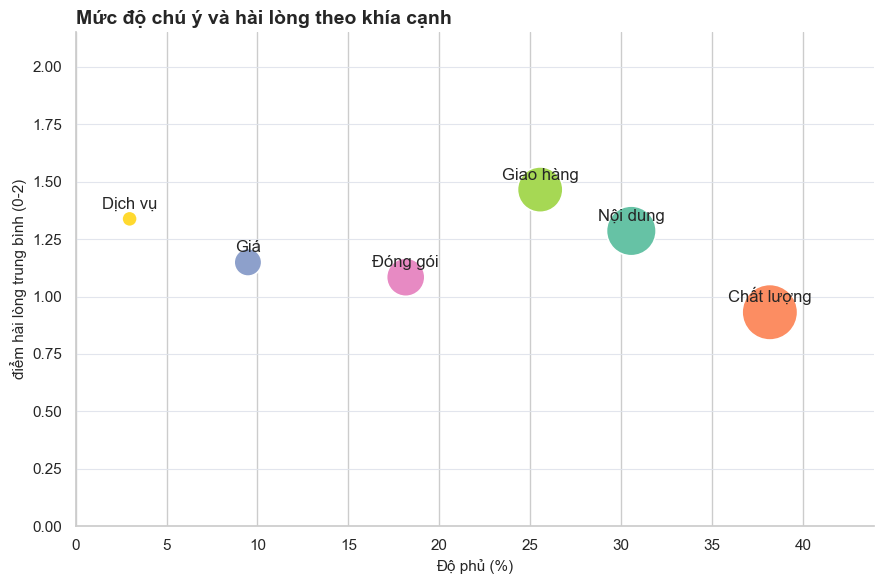

In [70]:
aspect_summary = []
for aspect in ASPECT_COLS:
    subset = df[[aspect]].dropna()
    if subset.empty:
        continue
    aspect_summary.append(
        {
            "aspect": aspect,
            "coverage": int(subset.shape[0]),
            "coverage_pct": float(subset.shape[0] * 100 / len(df)),
            "mean_score": float(subset[aspect].mean()),
        }
    )

aspect_summary = pd.DataFrame(aspect_summary)

fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(
    data=aspect_summary,
    x="coverage_pct",
    y="mean_score",
    hue="aspect",
    palette="Set2",
    size="coverage",
    sizes=(120, 1600),
    legend=False,
    ax=ax,
    edgecolor="white",
    linewidth=1.2,
)
for _, row in aspect_summary.iterrows():
    ax.text(
        row["coverage_pct"],
        row["mean_score"] + 0.03,
        display_aspect(row["aspect"]),
        ha="center",
        va="bottom",
    )
style_axes(ax)
ax.set_title("Mức độ chú ý và hài lòng theo khía cạnh", loc="left")
ax.set_xlabel("Độ phủ (%)")
ax.set_ylabel("điểm hài lòng trung bình (0-2)")
ax.set_xlim(0, max(aspect_summary["coverage_pct"]) * 1.15 if len(aspect_summary) else 1)
ax.set_ylim(0, 2.15)
plt.tight_layout()
plt.show()

Biểu đồ ma trận khía cạnh chỉ ra một nghịch lý: Khía cạnh quan trọng nhất là 'Chất lượng' lại đang nhận được mức độ hài lòng thấp nhất. Chiến lược cải thiện sản phẩm cần tập trung tối đa vào việc nâng cao chất lượng in ấn/đóng bản sách. Ngược lại, hệ thống có thể tiếp tục phát huy thế mạnh về 'Giao hàng' để duy trì lòng trung thành của khách hàng

## Biểu đồ radar: Sức mạnh của 6 khía cạnh


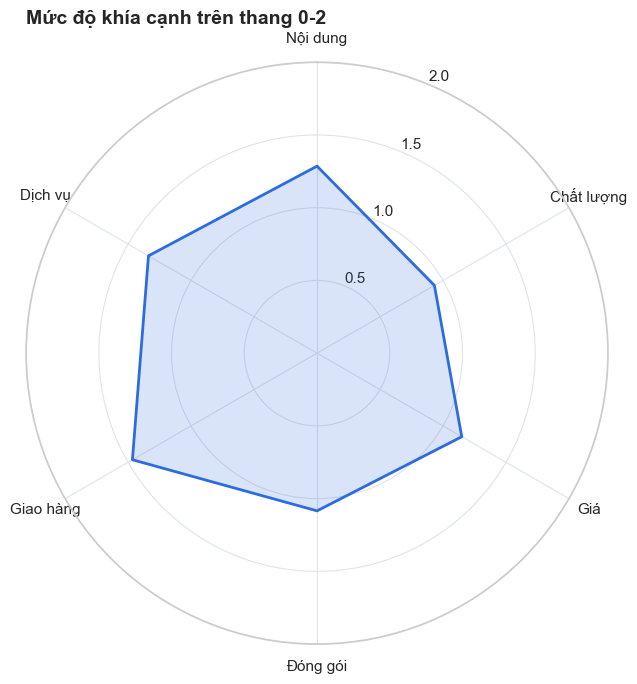

In [71]:
aspect_means = df[ASPECT_COLS].mean().fillna(0)
radar_labels = [display_aspect(aspect) for aspect in ASPECT_COLS]
radar_values = list(aspect_means.values)
radar_values.append(radar_values[0])
angles = np.linspace(0, 2 * np.pi, len(radar_labels), endpoint=False).tolist()
angles.append(angles[0])

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.plot(angles, radar_values, color="#2d6cdf", linewidth=2)
ax.fill(angles, radar_values, color="#2d6cdf", alpha=0.18)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels)
ax.set_yticks([0.5, 1.0, 1.5, 2.0])
ax.set_ylim(0, 2)
ax.grid(color="#dfe3eb", linewidth=0.8)
ax.set_title("Mức độ khía cạnh trên thang 0-2", loc="left")
plt.tight_layout()
plt.show()


Biểu đồ Radar cho thấy một 'vết sẹo' lớn tại khía cạnh Chất lượng. Tổng thể trải nghiệm khách hàng đang được gồng gánh bởi dịch vụ Giao hàng và Nội dung sách. Để biểu đồ này trở nên tròn trịa và đầy đặn hơn (biểu tượng cho sự hài lòng toàn diện), ưu tiên số 1 phải là giải quyết dứt điểm các phàn nàn về Chất lượng và tối ưu hóa thêm về Giá cả

## Bản đồ nhiệt: Ma trận tương quan giữa các khía cạnh


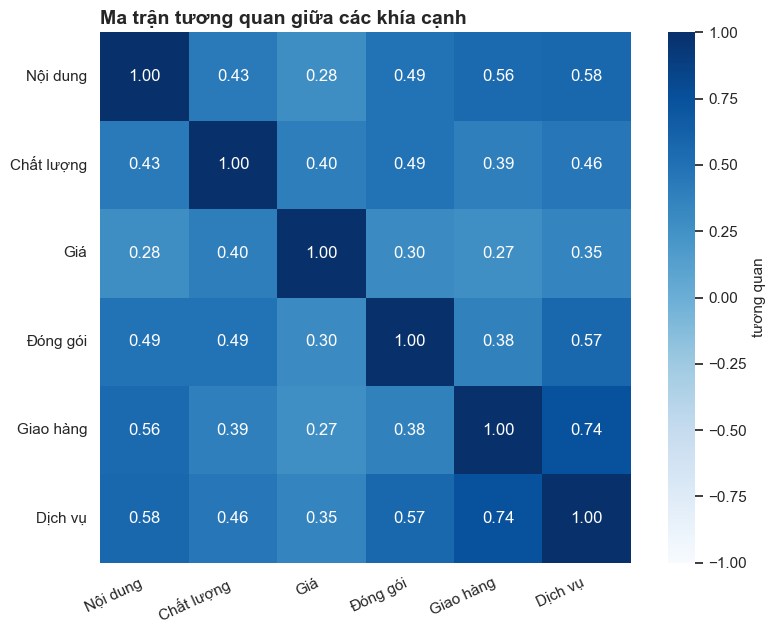

In [72]:
corr = df[ASPECT_COLS].corr()
heatmap_labels = [display_aspect(aspect) for aspect in ASPECT_COLS]

fig, ax = plt.subplots(figsize=(8.5, 6.5))
sns.heatmap(
    corr,
    cmap="Blues",
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    square=True,
    cbar_kws={"label": "tương quan"},
    ax=ax,
)
ax.set_xticklabels(heatmap_labels, rotation=25, ha="right")
ax.set_yticklabels(heatmap_labels, rotation=0)
ax.set_title("Ma trận tương quan giữa các khía cạnh", loc="left")
plt.tight_layout()
plt.show()

Ma trận tương quan chỉ ra rằng trải nghiệm khách hàng trong tập dữ liệu này có tính hệ thống cao. Đặc biệt, khâu 'Dịch vụ' và 'Giao hàng' đóng vai trò là xương sống kết nối toàn bộ sự hài lòng. Ngược lại, khía cạnh 'Giá' cần được phân tích như một yếu tố đứng riêng lẻ, ít bị tác động bởi các yếu tố dịch vụ xung quanh

## Biểu đồ phân tán: Độ đa dạng từ vựng và số từ


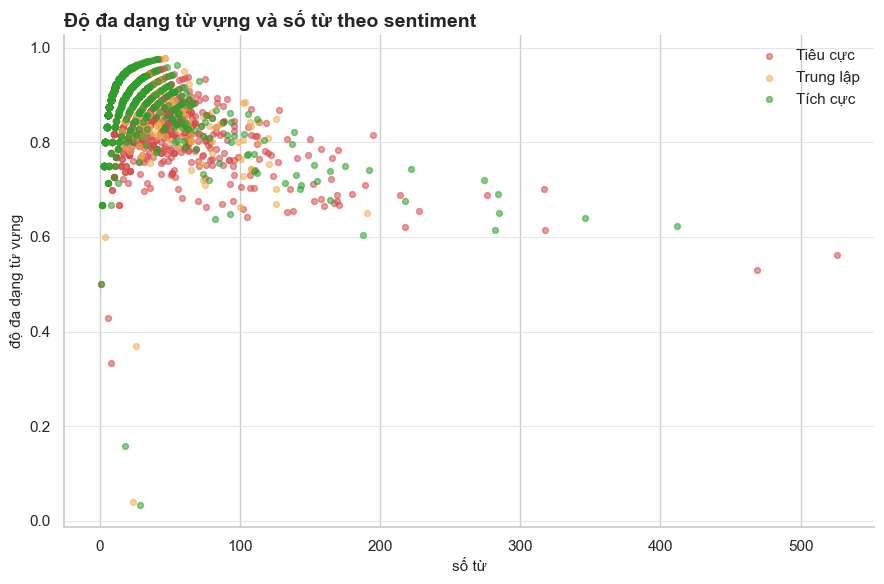

In [73]:
sample = df.sample(min(len(df), 3000), random_state=42)

fig, ax = plt.subplots(figsize=(9, 6))
for label in SENTIMENT_ORDER:
    subset = sample.loc[sample["sentiment_name"] == label]
    ax.scatter(
        subset["word_count"],
        subset["lexical_diversity"],
        s=18,
        alpha=0.55,
        label=display_sentiment(label),
        color=SENTIMENT_COLORS[label],
    )
style_axes(ax)
ax.set_title("Độ đa dạng từ vựng và số từ theo sentiment", loc="left")
ax.set_xlabel("số từ")
ax.set_ylabel("độ đa dạng từ vựng")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


Biểu đồ hành vi ngôn ngữ chỉ ra sự khác biệt tâm lý giữa người khen và người chê: Người viết review tích cực thường cô đọng và giàu vốn từ, trong khi người viết tiêu cực có xu hướng viết dài hơn (kể lể) và lặp lại từ ngữ nhiều hơn. Đối với mô hình AI, các câu review tích cực ngắn có thể mang lại 'tín hiệu' rõ ràng nhất, trong khi các câu tiêu cực dài cần hệ thống chú ý hơn vào ngữ cảnh để không bị nhiễu bởi các từ lặp lại

In [74]:
bigram_frames = {
    label: top_ngrams(
        sentiment_subset(df, label)["content"].map(normalize_text_for_ngrams).tolist(),
        ngram_range=(2, 2),
        top_n=15,
    )
    for label in SENTIMENT_ORDER
}

trigram_frames = {
    label: top_ngrams(
        sentiment_subset(df, label)["content"].map(normalize_text_for_ngrams).tolist(),
        ngram_range=(3, 3),
        top_n=10,
    )
    for label in SENTIMENT_ORDER
}

## Bảng tổng hợp 15 bigram hàng đầu


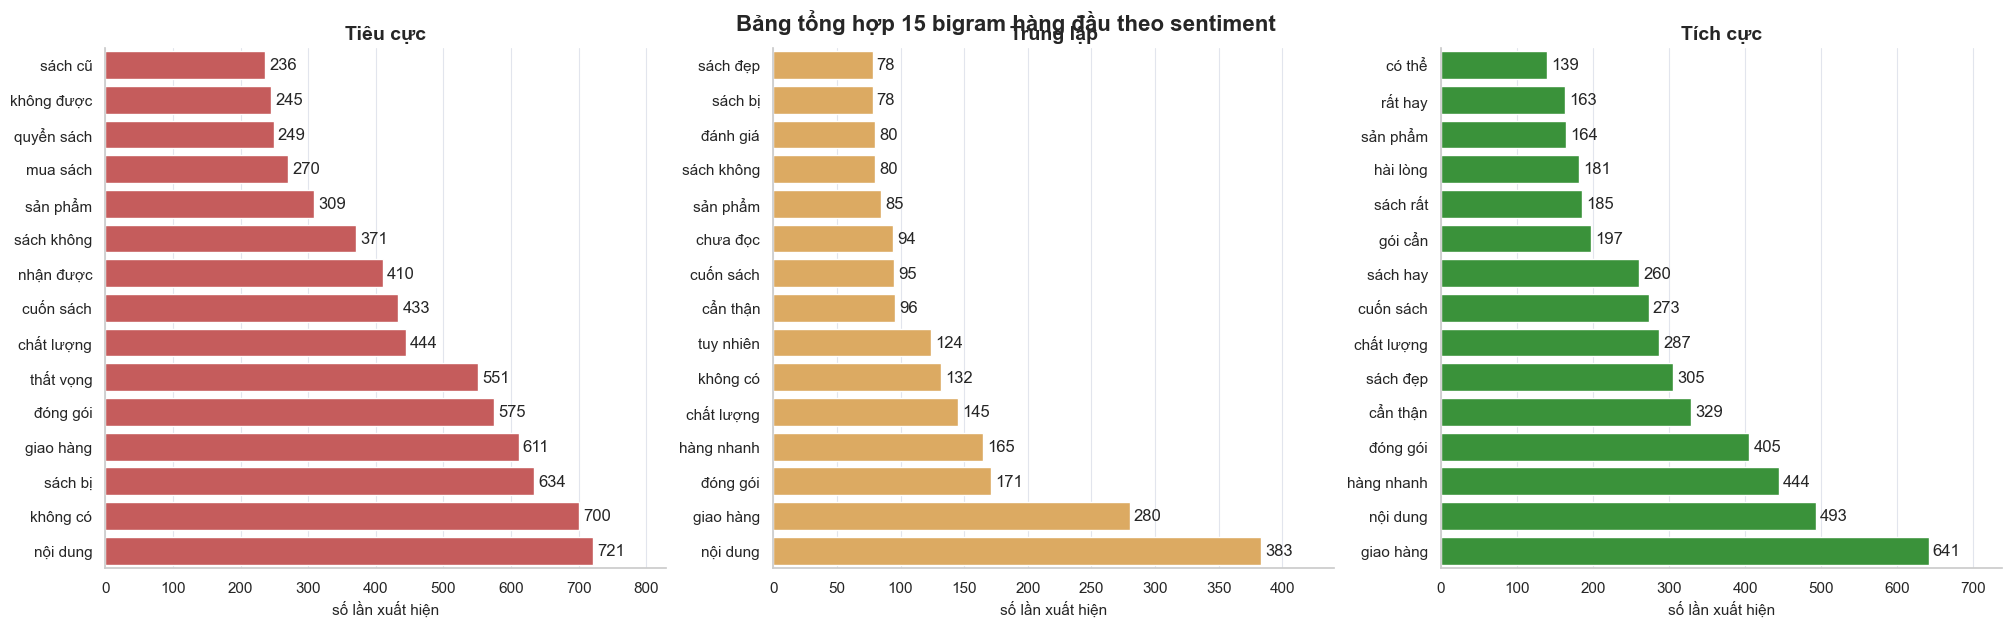

In [75]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), constrained_layout=True)
for ax, label in zip(axes, SENTIMENT_ORDER):
    frame = bigram_frames[label].nlargest(15, "count").sort_values("count")
    sns.barplot(
        data=frame,
        x="count",
        y="ngram",
        ax=ax,
        color=SENTIMENT_COLORS[label],
        errorbar=None,
        orient="h",
        order=frame["ngram"].tolist(),
    )
    style_axes(ax, grid_axis="x")
    ax.set_title(display_sentiment(label))
    ax.set_xlabel("số lần xuất hiện")
    ax.set_ylabel("")
    ax.set_xlim(0, frame["count"].max() * 1.15 if not frame.empty else 1)
    for container in ax.containers:
        ax.bar_label(container, fmt="{:,.0f}", padding=3)
fig.suptitle("Bảng tổng hợp 15 bigram hàng đầu theo sentiment", y=1.02, fontsize=16, fontweight="bold")
plt.show()

## Bảng tổng hợp 10 trigram hàng đầu


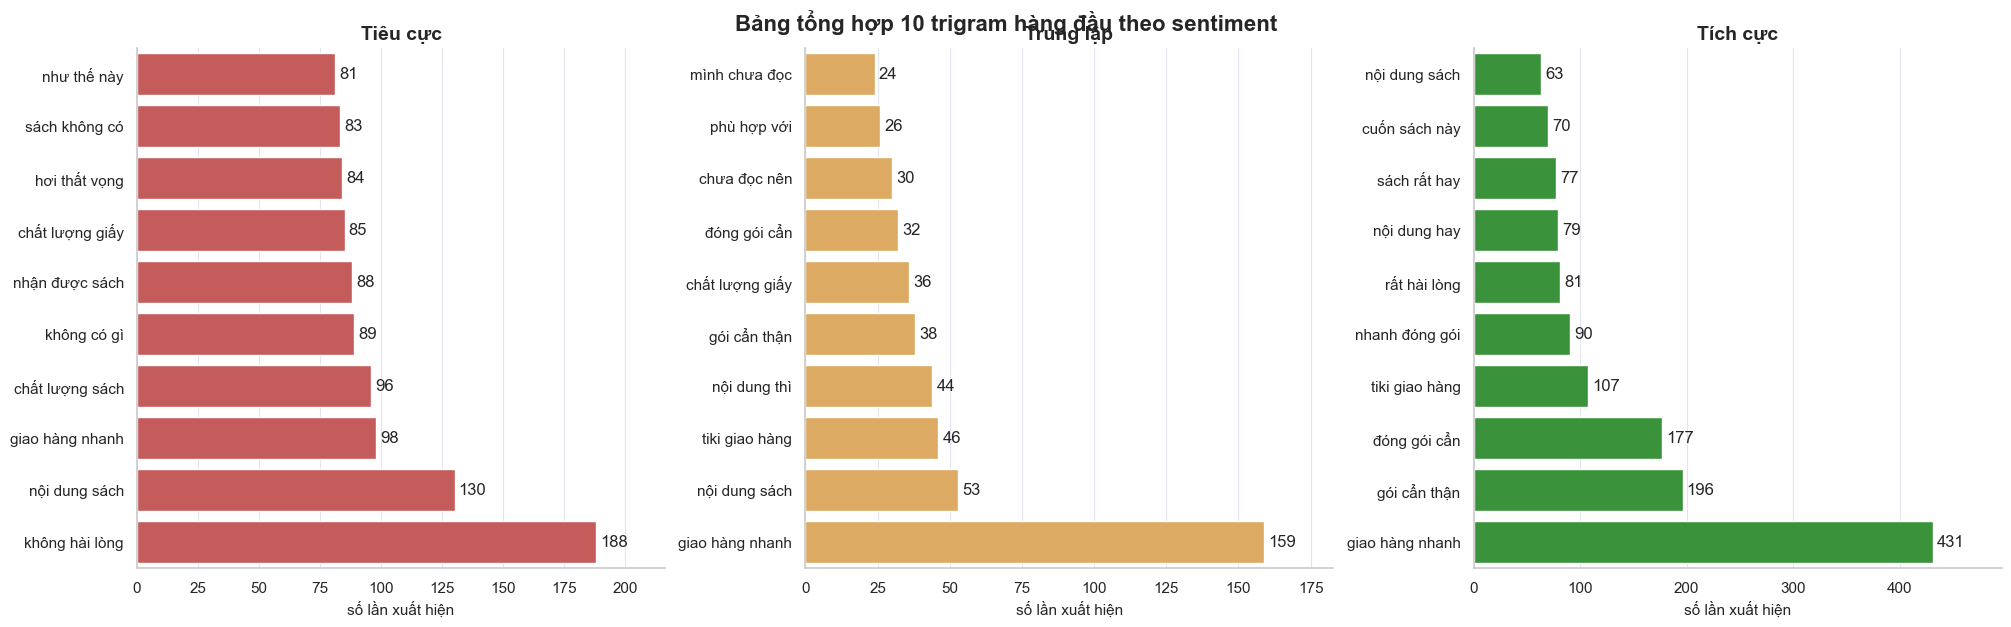

In [76]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), constrained_layout=True)
for ax, label in zip(axes, SENTIMENT_ORDER):
    frame = trigram_frames[label].nlargest(10, "count").sort_values("count")
    sns.barplot(
        data=frame,
        x="count",
        y="ngram",
        ax=ax,
        color=SENTIMENT_COLORS[label],
        errorbar=None,
        orient="h",
        order=frame["ngram"].tolist(),
    )
    style_axes(ax, grid_axis="x")
    ax.set_title(display_sentiment(label))
    ax.set_xlabel("số lần xuất hiện")
    ax.set_ylabel("")
    ax.set_xlim(0, frame["count"].max() * 1.15 if not frame.empty else 1)
    for container in ax.containers:
        ax.bar_label(container, fmt="{:,.0f}", padding=3)
fig.suptitle("Bảng tổng hợp 10 trigram hàng đầu theo sentiment", y=1.02, fontsize=16, fontweight="bold")
plt.show()

## Bảng Word Cloud


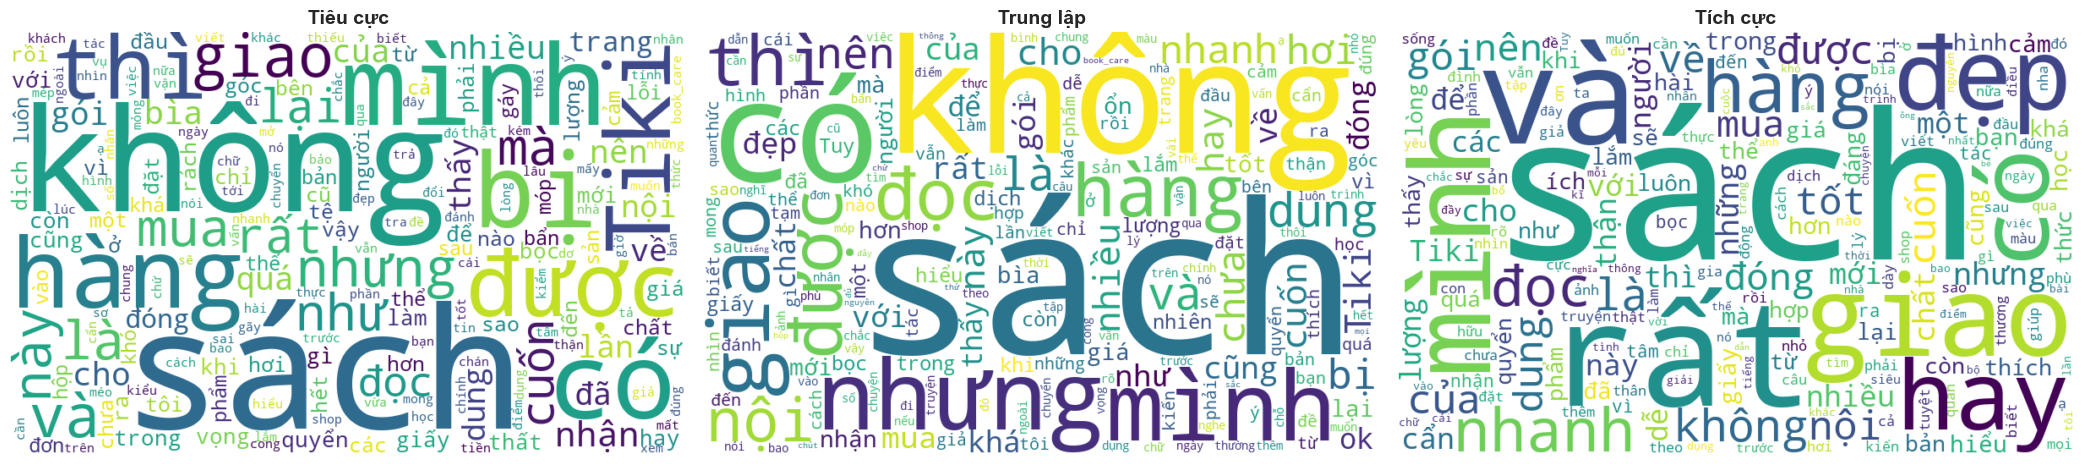

In [77]:
fig, axes = plt.subplots(1, 3, figsize=(21, 7))
for ax, label in zip(axes, SENTIMENT_ORDER):
    text = " ".join(sentiment_subset(df, label)["content"].tolist())
    wc = WordCloud(
        width=800,
        height=500,
        background_color="white",
        collocations=False,
        colormap="viridis",
    ).generate(text if text.strip() else "empty")
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(display_sentiment(label))
    ax.axis("off")
plt.tight_layout()
plt.show()

## Biểu đồ phân tán 3D: TF-IDF + t-SNE


In [78]:
sample_parts = []
for label in SENTIMENT_ORDER:
    subset = df.loc[df["sentiment_name"] == label]
    if subset.empty:
        continue
    sample_parts.append(subset.sample(min(len(subset), 300), random_state=42))

sample_3d = pd.concat(sample_parts, ignore_index=True)
texts_3d = sample_3d["content"].map(normalize_text_for_ngrams).tolist()

tfidf_3d = TfidfVectorizer(max_features=1200, ngram_range=(1, 2), min_df=2)
x_tfidf_3d = tfidf_3d.fit_transform(texts_3d)

n_components_3d = min(50, max(2, x_tfidf_3d.shape[1] - 1))
svd_3d = TruncatedSVD(n_components=n_components_3d, random_state=42)
x_reduced_3d = svd_3d.fit_transform(x_tfidf_3d)

perplexity_3d = min(30, max(5, len(sample_3d) // 10))
tsne_3d = TSNE(
    n_components=3,
    random_state=42,
    perplexity=perplexity_3d,
    init="pca",
    learning_rate="auto",
)
coords_3d = tsne_3d.fit_transform(x_reduced_3d)

plot_df_3d = sample_3d.copy()
plot_df_3d["x"] = coords_3d[:, 0]
plot_df_3d["y"] = coords_3d[:, 1]
plot_df_3d["z"] = coords_3d[:, 2]


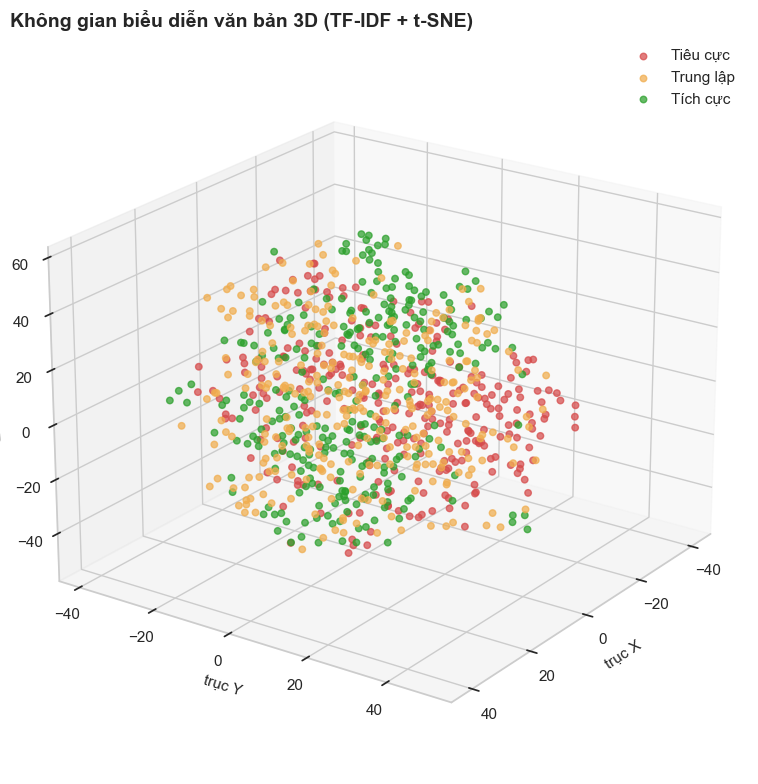

In [79]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")
for label in SENTIMENT_ORDER:
    subset = plot_df_3d.loc[plot_df_3d["sentiment_name"] == label]
    ax.scatter(
        subset["x"],
        subset["y"],
        subset["z"],
        s=22,
        alpha=0.72,
        label=display_sentiment(label),
        color=SENTIMENT_COLORS[label],
        depthshade=True,
    )
ax.set_title("Không gian biểu diễn văn bản 3D (TF-IDF + t-SNE)", loc="left")
ax.set_xlabel("trục X")
ax.set_ylabel("trục Y")
ax.set_zlabel("trục Z")
ax.view_init(elev=22, azim=35)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


## Ghi chú

- Dashboard này chỉ dùng cho tập train.
- Số emoji được giữ như một feature bổ trợ cho sentiment.
- N-gram, word cloud và embedding được tính từ `content` đã làm sạch.
- GitHub preview dùng các output Matplotlib tĩnh và ảnh xem trước ở đầu notebook.